# Similarity Search — Interactive Exploration

Visualize the synthetic dataset, step through each index type on a single query, and plot the
recall-vs-latency trade-off across all five methods. See `README.md` for setup, and
`../docs/Similarity_Search_Methods/` for the algorithms explained in depth.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

from brute_force import BruteForceIndex
from data import make_dataset, make_queries
from graph_ann import HNSWIndex
from ivf_pq import IVFPQIndex
from lsh import LSHIndex
from metrics import dot_product
from tree_methods import TreeIndex

vectors, cluster_ids, centers = make_dataset(n_vectors=20_000, dim=128)
queries = make_queries(centers, n_queries=200)
print(vectors.shape, queries.shape)

(20000, 128) (200, 128)


## 1. What does the dataset look like?

128 dimensions can't be plotted directly — project down to 2D with PCA just to build intuition
for the cluster structure every index below is exploiting.

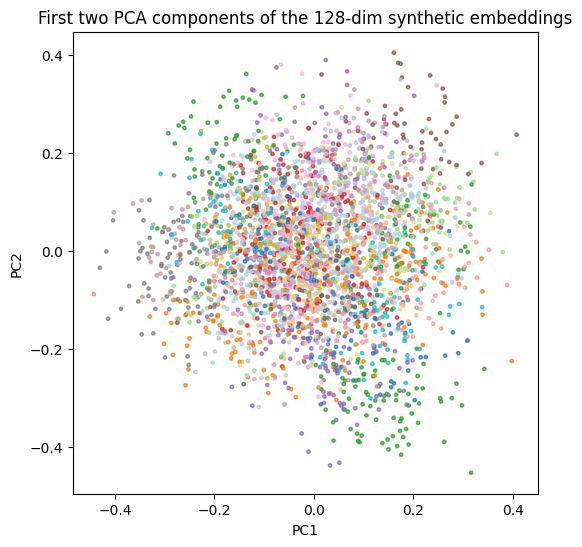

In [2]:
coords_2d = PCA(n_components=2).fit_transform(vectors[:3000])
plt.figure(figsize=(6, 6))
plt.scatter(coords_2d[:, 0], coords_2d[:, 1], c=cluster_ids[:3000], cmap="tab20", s=6, alpha=0.7)
plt.title("First two PCA components of the 128-dim synthetic embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## 2. One query, five methods

Run the same query through every index and compare which neighbors (and scores) each one
returns against the brute-force ground truth.

In [3]:
query = queries[0]
k = 10

brute = BruteForceIndex(vectors)
ground_truth = brute.search(query, k)

indexes = {
    "KD-Tree": TreeIndex(vectors, kind="kd"),
    "Ball-Tree": TreeIndex(vectors, kind="ball"),
    "LSH": LSHIndex(vectors),
    "HNSW": HNSWIndex(vectors),
    "IVF-PQ": IVFPQIndex(vectors),
}

print("Brute force (ground truth):", ground_truth, "\n")
for name, index in indexes.items():
    result = index.search(query, k)
    overlap = len(set(result) & set(ground_truth))
    print(f"{name:10s} overlap={overlap}/{k}  neighbors={result}")

Brute force (ground truth): [ 6721 15542 12650  6496  8801  9179 19742  3353   410 15773] 

KD-Tree    overlap=10/10  neighbors=[ 6721 15542 12650  6496  8801  9179 19742  3353   410 15773]
Ball-Tree  overlap=10/10  neighbors=[ 6721 15542 12650  6496  8801  9179 19742  3353   410 15773]
LSH        overlap=10/10  neighbors=[ 6721 15542 12650  6496  8801  9179 19742  3353   410 15773]
HNSW       overlap=10/10  neighbors=[ 6721 15542 12650  6496  8801  9179 19742  3353   410 15773]
IVF-PQ     overlap=6/10  neighbors=[ 4875  6721 15542  6496 12650 19742 15773  8318 15151 16737]


## 3. Recall vs. latency across all methods

The trade-off every ANN method is negotiating: how much recall are you willing to give up for
how much speed? Re-running `benchmark.py`'s logic here so we can plot it directly.

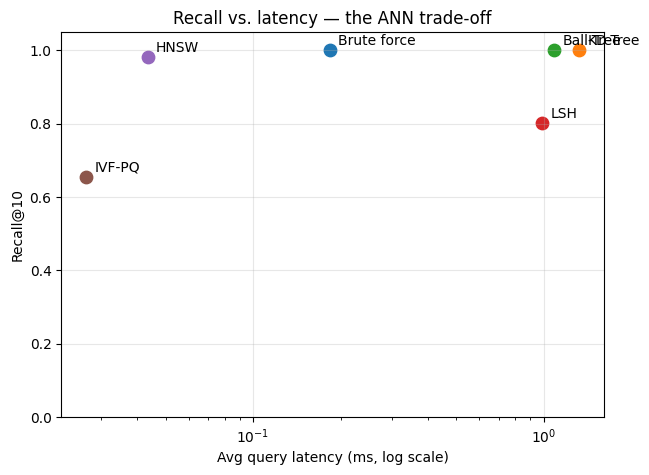

In [4]:
ground_truth_all = [brute.search(q, k) for q in queries]


def recall_at_k(results, truth):
    hits = sum(len(set(a) & set(g)) for a, g in zip(results, truth))
    total = sum(len(g) for g in truth)
    return hits / total


points = []
for name, index in {"Brute force": brute, **indexes}.items():
    start = time.perf_counter()
    results = [index.search(q, k) for q in queries]
    avg_ms = (time.perf_counter() - start) * 1000 / len(queries)
    recall = recall_at_k(results, ground_truth_all)
    points.append((name, avg_ms, recall))

plt.figure(figsize=(7, 5))
for name, avg_ms, recall in points:
    plt.scatter(avg_ms, recall, s=80)
    plt.annotate(name, (avg_ms, recall), textcoords="offset points", xytext=(6, 4))
plt.xscale("log")
plt.xlabel("Avg query latency (ms, log scale)")
plt.ylabel("Recall@10")
plt.title("Recall vs. latency — the ANN trade-off")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.show()